    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [15]:
inds_10 = pd.read_csv('csv/10_industry.csv')
inds_10['Date'] = pd.to_datetime(inds_10['Date'])
inds_10 = inds_10.set_index('Date')
inds_10.info()
inds_10

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   6539 non-null   float64
 1   Durbl   6539 non-null   float64
 2   Manuf   6539 non-null   float64
 3   Enrgy   6539 non-null   float64
 4   HiTec   6539 non-null   float64
 5   Telcm   6539 non-null   float64
 6   Shops   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Utils   6539 non-null   float64
 9   Other   6539 non-null   float64
dtypes: float64(10)
memory usage: 561.9 KB


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
2000-01-03,-1.65,-1.36,-2.49,-3.08,2.47,-1.26,-2.30,-0.58,-2.37,-3.31
2000-01-04,-1.81,-2.60,-2.68,-1.96,-5.34,-4.40,-3.28,-4.39,0.47,-3.68
2000-01-05,-0.13,-0.04,0.57,2.26,-1.09,0.01,-0.38,2.32,3.48,-0.38
2000-01-06,0.68,0.58,2.17,4.00,-4.93,-1.92,0.24,2.68,0.57,2.34
2000-01-07,2.11,4.81,3.21,1.16,3.51,0.93,4.27,7.61,1.13,1.99
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.36,0.00,0.46,-0.33,0.17,0.64,0.51,0.58,0.38,0.42
2025-12-26,-0.07,-1.65,-0.13,-0.30,0.09,-0.18,0.13,-0.05,-0.16,-0.05
2025-12-29,0.19,-2.68,-0.38,1.02,-0.40,0.43,-0.21,-0.26,0.26,-0.57


In [16]:
torch.manual_seed(42)

N_STOCKS   = len(inds_10.columns)
LOOKBACK   = 21
HORIZON    = 21

INPUT_DIM  = LOOKBACK * N_STOCKS
HIDDEN_DIM = 64
N          = HORIZON
M          = N_STOCKS

n1    = 0.50
C     = 1.0
d     = 1.0
x_min = 0.02
x_max = 0.25
gamma = 0.05
lam   = 0.7

EPOCHS     = 200
BATCH_SIZE = 16
LR         = 1e-4

In [17]:
inds_10 = inds_10.sort_index()   # ← 이 한 줄 추가
inds_10 = inds_10[~inds_10.index.duplicated(keep='first')]  # ← 없음
inds_10 = inds_10 / 100.0

stock_names = inds_10.columns.tolist()

# =============================================================================
# 2. IS / OOS 분리 (날짜 기준)
# =============================================================================
IS_START = "2000-01-01"
IS_END   = "2017-12-31"
BT_START = "2018-01-01"
BT_END   = "2025-12-31"

is_df = inds_10[IS_START : IS_END]
bt_df = inds_10[BT_START : BT_END]

is_np  = is_df.values
bt_np  = bt_df.values

N_IS   = len(is_df)
N_BT   = len(bt_df)
N_DAYS = len(inds_10)

print(f"전체 : {inds_10.index[0].date()} → {inds_10.index[-1].date()}  ({N_DAYS} days)")
print(f"IS   : {is_df.index[0].date()} → {is_df.index[-1].date()}  ({N_IS} days)")
print(f"BT   : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목 : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
is_mean = is_np.mean(axis=0)   # shape (10,)
is_std  = is_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (21, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # IS 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

is_samples = make_windows(is_np, LOOKBACK, HORIZON,
                          start=LOOKBACK, end=N_IS)

full_np      = np.vstack([is_np, bt_np])
BT_START_IDX = N_IS

rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                             start=BT_START_IDX, end=BT_START_IDX + N_BT)
rebal_samples = rebal_samples[::HORIZON]

is_years = (is_df.index[-1] - is_df.index[0]).days / 365.25
bt_years = (bt_df.index[-1] - bt_df.index[0]).days / 365.25

print(f"\nIS 학습 샘플 수  : {len(is_samples)}")
print(f"BT 리밸런싱 횟수 : {len(rebal_samples)}")


전체 : 2000-01-03 → 2025-12-31  (6539 days)
IS   : 2000-01-03 → 2017-12-29  (4528 days)
BT   : 2018-01-02 → 2025-12-31  (2011 days)
종목 : ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

IS 학습 샘플 수  : 4487
BT 리밸런싱 횟수 : 95



── IS Training ──
  Epoch   1/200  loss = 0.005670
  Epoch   5/200  loss = 0.003929
  Epoch  10/200  loss = 0.003761
  Epoch  15/200  loss = 0.003462
  Epoch  20/200  loss = 0.003130
  Epoch  25/200  loss = 0.002949
  Epoch  30/200  loss = 0.002580
  Epoch  35/200  loss = 0.002443
  Epoch  40/200  loss = 0.002236
  Epoch  45/200  loss = 0.002006
  Epoch  50/200  loss = 0.001682
  Epoch  55/200  loss = 0.001362
  Epoch  60/200  loss = 0.001092
  Epoch  65/200  loss = 0.000948
  Epoch  70/200  loss = 0.000650
  Epoch  75/200  loss = 0.000451
  Epoch  80/200  loss = 0.000248
  Epoch  85/200  loss = 0.000004
  Epoch  90/200  loss = -0.000127
  Epoch  95/200  loss = -0.000319
  Epoch 100/200  loss = -0.000483
  Epoch 105/200  loss = -0.000557


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/diffcp/cone_program.py:522: UserWarning: Solved/Inaccurate.
  warnings.warn("Solved/Inaccurate.")


  Epoch 110/200  loss = -0.000922
  Epoch 115/200  loss = -0.000873
  Epoch 120/200  loss = -0.001121
  Epoch 125/200  loss = -0.001275
  Epoch 130/200  loss = -0.001258
  Epoch 135/200  loss = -0.001478
  Epoch 140/200  loss = -0.001607
  Epoch 145/200  loss = -0.001681
  Epoch 150/200  loss = -0.001772
  Epoch 155/200  loss = -0.001912
  Epoch 160/200  loss = -0.002037
  Epoch 165/200  loss = -0.002195
  Epoch 170/200  loss = -0.002321
  Epoch 175/200  loss = -0.002413
  Epoch 180/200  loss = -0.002631
  Epoch 185/200  loss = -0.002745
  Epoch 190/200  loss = -0.002756
  Epoch 195/200  loss = -0.002952
  Epoch 200/200  loss = -0.003183

── Backtest : DFL-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 698.12it/s]

    1    0.0335   1.3497%  {'Utils': 0.25, 'HiTec': 0.25, 'NoDur': 0.25}
    2   -0.0508   6.9241%  {'Utils': 0.25, 'Shops': 0.25, 'NoDur': 0.25}
    3   -0.0263   7.0183%  {'Shops': 0.25, 'Manuf': 0.25, 'Durbl': 0.25}
    4    0.0047   3.6592%  {'Telcm': 0.25, 'Enrgy': 0.25, 'NoDur': 0.25}
    5    0.0226   0.7904%  {'Utils': 0.25, 'Hlth': 0.25, 'NoDur': 0.25}
    6    0.0133   2.5901%  {'Shops': 0.25, 'Durbl': 0.25, 'NoDur': 0.25}
    7    0.0217   0.8076%  {'Utils': 0.25, 'Shops': 0.25, 'Telcm': 0.25}
    8    0.0209   1.2795%  {'Hlth': 0.25, 'Telcm': 0.25, 'NoDur': 0.25}
    9    0.0047   1.4761%  {'Utils': 0.25, 'Shops': 0.25, 'NoDur': 0.25}
   10   -0.0413   5.5935%  {'Utils': 0.25, 'Shops': 0.25, 'NoDur': 0.25}
   11    0.0256   4.7965%  {'Utils': 0.25, 'Enrgy': 0.25, 'Durbl': 0.25}
   12   -0.0892  15.6553%  {'Utils': 0.25, 'Enrgy': 0.25, 'NoDur': 0.25}
   13    0.0656   1.1005%  {'Utils': 0.25, 'Telcm': 0.25, 'NoDur': 0.25}
   14    0.0266   1.0781%  {'Utils': 0.25, 'Enrgy': 0

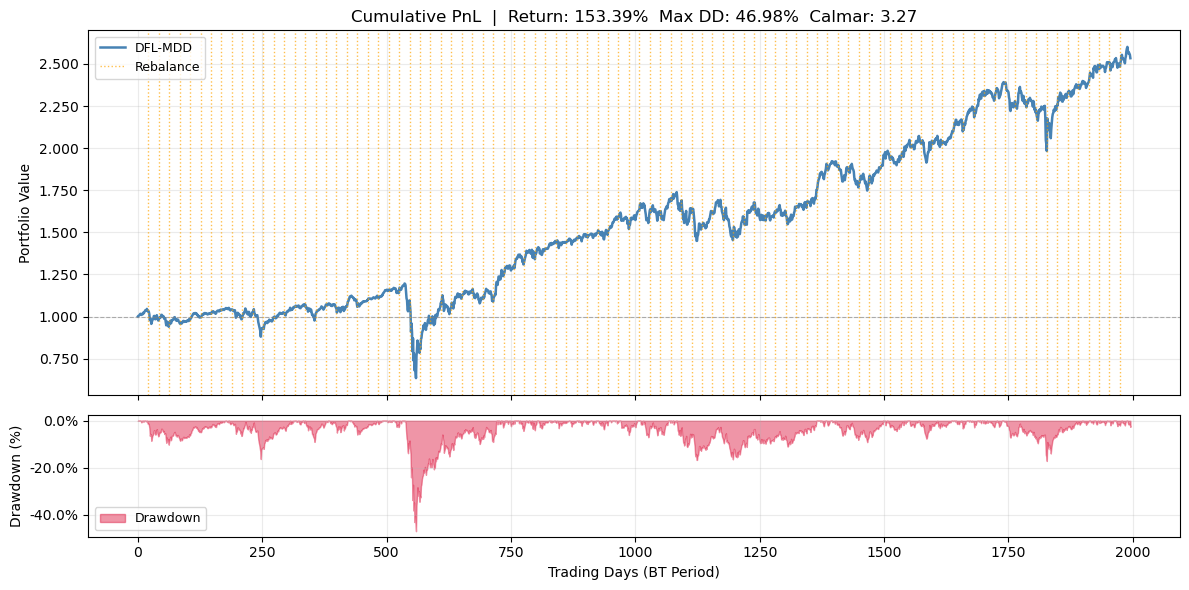


── PnL Summary (DFL-MDD) ──
  Final Value  : 2.5339
  Total Return : 153.3924%
  Max Drawdown : 46.9773%
  Calmar Ratio : 3.2652


In [18]:
import importlib
import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel,
    build_optimization_layer,
    solve_portfolio,
    compute_cumulative_path,
    compute_realized_path,
    compute_return,
    compute_max_drawdown,
    dfl_loss,
    forward_pass,
    backtest_dfl_mdd,
    plot_pnl,
)

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False 

pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M, 0.1)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)


zs_is = torch.tensor(np.array([s[0] for s in is_samples]), dtype=torch.float32)
rs_is = torch.tensor(np.array([s[1] for s in is_samples]), dtype=torch.float32)

print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


bt_dfl_mdd = backtest_dfl_mdd(
    pred_model    = pred_model,
    opt_layer     = opt_layer,
    rebal_samples = rebal_samples,
    N             = HORIZON,
    d             = d,
    C             = C,
    n1            = n1,
    x_min         = x_min,
    x_max         = x_max,
    stock_names   = stock_names,
)


plot_pnl(bt_dfl_mdd, horizon=HORIZON, label = "DFL-MDD")


── PTO-MDD Training (MSE) ──
  Epoch   1/200  mse = 0.006234
  Epoch   5/200  mse = 0.000455
  Epoch  10/200  mse = 0.000234
  Epoch  15/200  mse = 0.000202
  Epoch  20/200  mse = 0.000194
  Epoch  25/200  mse = 0.000191
  Epoch  30/200  mse = 0.000191
  Epoch  35/200  mse = 0.000189
  Epoch  40/200  mse = 0.000188
  Epoch  45/200  mse = 0.000187
  Epoch  50/200  mse = 0.000185
  Epoch  55/200  mse = 0.000183
  Epoch  60/200  mse = 0.000182
  Epoch  65/200  mse = 0.000180
  Epoch  70/200  mse = 0.000179
  Epoch  75/200  mse = 0.000178
  Epoch  80/200  mse = 0.000177
  Epoch  85/200  mse = 0.000176
  Epoch  90/200  mse = 0.000175
  Epoch  95/200  mse = 0.000174
  Epoch 100/200  mse = 0.000173
  Epoch 105/200  mse = 0.000172
  Epoch 110/200  mse = 0.000171
  Epoch 115/200  mse = 0.000171
  Epoch 120/200  mse = 0.000170
  Epoch 125/200  mse = 0.000170
  Epoch 130/200  mse = 0.000169
  Epoch 135/200  mse = 0.000168
  Epoch 140/200  mse = 0.000168
  Epoch 145/200  mse = 0.000167
  Epoch 15

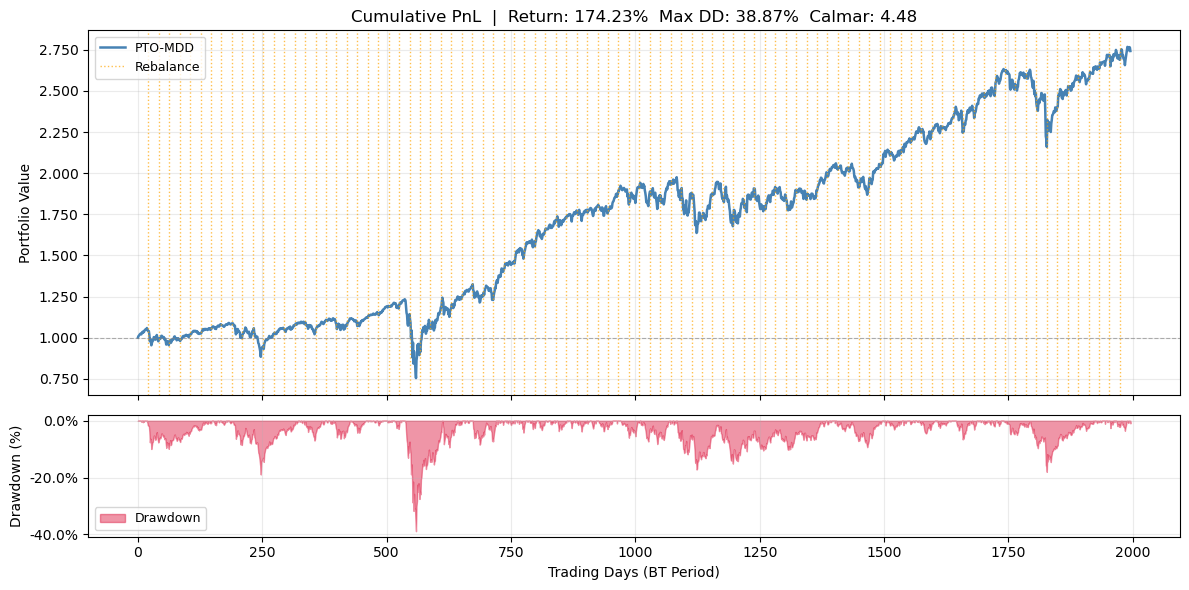


── PnL Summary (PTO-MDD) ──
  Final Value  : 2.7423
  Total Return : 174.2284%
  Max Drawdown : 38.8688%
  Calmar Ratio : 4.4825


In [19]:
import importlib
import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd  import train_pto_mdd,  backtest_pto_mdd

model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)


bt_pto_mdd = backtest_pto_mdd(
    pred_model   = model_pto_mdd,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    n1           = n1,
    x_min        = x_min,
    x_max        = x_max,
    gamma        = 0.1,
    stock_names  = stock_names,
)


plot_pnl(bt_pto_mdd, horizon=HORIZON, label = 'PTO-MDD')



── PTO-MVO Training (MSE) ──
  Epoch   1/200  mse = 0.005695
  Epoch   5/200  mse = 0.000453
  Epoch  10/200  mse = 0.000236
  Epoch  15/200  mse = 0.000203
  Epoch  20/200  mse = 0.000194
  Epoch  25/200  mse = 0.000191
  Epoch  30/200  mse = 0.000190
  Epoch  35/200  mse = 0.000188
  Epoch  40/200  mse = 0.000187
  Epoch  45/200  mse = 0.000185
  Epoch  50/200  mse = 0.000183
  Epoch  55/200  mse = 0.000182
  Epoch  60/200  mse = 0.000180
  Epoch  65/200  mse = 0.000178
  Epoch  70/200  mse = 0.000176
  Epoch  75/200  mse = 0.000174
  Epoch  80/200  mse = 0.000173
  Epoch  85/200  mse = 0.000171
  Epoch  90/200  mse = 0.000170
  Epoch  95/200  mse = 0.000169
  Epoch 100/200  mse = 0.000167
  Epoch 105/200  mse = 0.000166
  Epoch 110/200  mse = 0.000165
  Epoch 115/200  mse = 0.000164
  Epoch 120/200  mse = 0.000163
  Epoch 125/200  mse = 0.000163
  Epoch 130/200  mse = 0.000161
  Epoch 135/200  mse = 0.000161
  Epoch 140/200  mse = 0.000160
  Epoch 145/200  mse = 0.000160
  Epoch 15

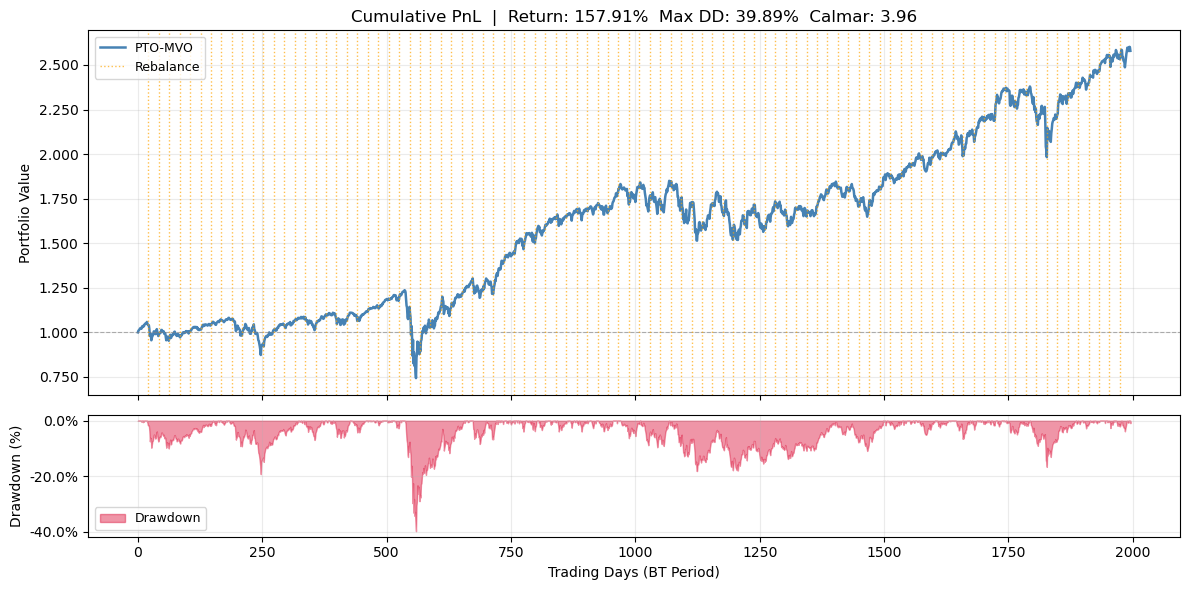


── PnL Summary (PTO-MVO) ──
  Final Value  : 2.5791
  Total Return : 157.9111%
  Max Drawdown : 39.8901%
  Calmar Ratio : 3.9587


In [20]:
import importlib
import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo  import train_pto_mvo,  backtest_pto_mvo 

model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)

bt_pto_mvo = backtest_pto_mvo(
    pred_model   = model_pto_mvo,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    lam_mvo      = 1.0,
    x_min        = x_min,
    x_max        = x_max,
    gamma        = 0.1,
    stock_names  = stock_names,
)

plot_pnl(bt_pto_mvo, horizon=HORIZON, label = 'PTO-MVO')